## Question Description

In the context of global agricultural sustainability, countries differ significantly in how efficiently they utilize environmental resources. To better understand these differences, this task applies unsupervised machine learning techniques to group countries based on their resource efficiency indicators.

The objectives of this task are:
- Construct resource efficiency metrics such as GHG emissions, water use, energy consumption, and pesticide application per unit of agricultural output;
- Apply clustering algorithms (e.g., K-Means) to identify 2–4 clusters of countries (e.g., high-efficiency, mixed-type, resource-intensive);
- Interpret the structural differences between these clusters to inform tailored agricultural sustainability policies;
- Provide benchmarking targets for developing countries to identify and learn from best-practice peers.

The clustering results will be visualized using PCA and serve as the basis for deeper efficiency comparison and interpretation in subsequent analyses.

## Import Libraries

In [1]:
try:
    import mpld3
except ImportError:
    !pip install mpld3
    import mpld3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 3.6 MB/s eta 0:00:00


In [2]:
try:
    import pycountry
except ImportError:
    !pip install pycountry
    import pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 19.4 MB/s eta 0:00:00


In [3]:
try:
    import dash
except ImportError:
    !pip install dash
    import dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.1
    Uninstalling Flask-3.1.1:
      Successfully uninstalled Flask-3.1.1


In [4]:
from __future__ import annotations

from pathlib import Path
from math import pi
from typing import Tuple, List
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from dash import dcc, html, Input, Output, State
from plotly.subplots import make_subplots
from matplotlib import MatplotlibDeprecationWarning

import seaborn as sns
import mpld3
import dash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.express as px
import plotly.graph_objs as go
import argparse
import pycountry
import warnings
import plotly.graph_objects as go

In [5]:
from google.colab import drive
drive.mount('/content/gdrive/')

%cd 'gdrive/My Drive/BigDataProject'

Mounted at /content/gdrive/
/content/gdrive/My Drive/BigDataProject


### Warning Message Process

In [6]:
# Suppress deprecation warnings related to converter attribute in mpld3
warnings.filterwarnings(
    "ignore",
    category=MatplotlibDeprecationWarning,
    module=r"mpld3\.mplexporter\.utils"
)

## Data Wrangling

As demonstrated throughout the data preprocessing section of our project, the merged dataframe suffered from severe data missingness that rendered it unusable without proper treatment. Therefore, the df subsequently employed was a rigorously filtered subset with interpolated values, which we will briefly visualize and assess later in this documentation.

### Load and Pre-process Data

In this section, we begin by loading the raw dataset from a local CSV file and standardizing the column names by shorter column names

In [7]:
def load_and_prepare() -> Tuple[pd.DataFrame, List[str], StandardScaler]:
    """Load the CSV, create per-hectare indicators, impute, scale."""
    df = pd.read_csv(DATA_PATH)

    # 1. Drop rows with missing/zero land area
    df = df[df[LAND_COL].notna() & (df[LAND_COL] > 0)]

    # 2. Derive per-hectare metrics
    for new_col, numerator in RAW_COLS.items():
        df[new_col] = df[numerator] / df[LAND_COL]

    # 3. Keep only valid features and fill missing values
    features = list(RAW_COLS.keys())
    valid_features = [c for c in features if df[c].notna().any() and df[c].std(skipna=True) > 0]
    dropped = set(features) - set(valid_features)
    if dropped:
        print(f"[Info] Skipped zero-variance / missing features: {', '.join(dropped)}")

    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(df[valid_features])

    # 4. Column-wise standardisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    scaled_cols = [f"{c}_scaled" for c in valid_features]
    df_scaled = pd.DataFrame(X_scaled, columns=scaled_cols, index=df.index)

    df = pd.concat([df, df_scaled], axis=1)
    return df, scaled_cols, scaler

### Column Name Process

In [8]:
DATA_PATH: Path = Path("scores_updated.csv")
LAND_COL = "Total agricultural land area (Hectares)"
RAW_COLS = {
    "ghg_per_ha": 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)',
    "energy_per_ha": "Direct on-farm energy consumption (Tonnes of oil equivalent)",
    "pesticide_per_ha": 'Total sales of agricultural pesticides (Tonnes)',
    "calorie_per_ha": "Total calorie availability (Kilocalories per person per day)",
}

In [9]:
# Short labels for radar-chart tick marks
SHORT_LABELS = {
    "ghg_per_ha": "GHG/ha",
    "energy_per_ha": "Energy/ha",
    "pesticide_per_ha": "Pesticide/ha",
    "calorie_per_ha": "Calories/ha",
}

After loading the data, we derive four per-hectare metrics—GHG, pesticide, calories, and energy consumption—impute missing values using the median strategy, and standardize each feature. These steps produce a clean, normalized feature set suitable for clustering.

In [10]:
# Data preparation: derive per-hectare metrics, handle missing values, normalization
df, scaled_cols, scaler = load_and_prepare()

### View the DataFrame

In [11]:
df.head()

,Country,Year,Frequency of observation,Direct on-farm energy consumption (Tonnes of oil equivalent),Food fat availability (Grammes per person per day),Food protein availability (Grammes per person per day),Producer Support Estimate (PSE) (US dollar),Total Support Estimate (TSE) (US dollar),Total agricultural land area (Hectares),Total calorie availability (Kilocalories per person per day),...,eff score,sust score,ghg_per_ha,energy_per_ha,pesticide_per_ha,calorie_per_ha,ghg_per_ha_scaled,energy_per_ha_scaled,pesticide_per_ha_scaled,calorie_per_ha_scaled
0,Argentina,2012,Annual,3751.70,0.0,99.69,4220.135,6667.835,124741.9,2986.50,...,0.280783,0.180357,2.490504,0.030076,2.046739,0.023941,-0.408692,-0.474014,-0.018765,-0.458482
1,Argentina,2013,Annual,4178.42,0.0,100.82,4220.135,6667.835,122937.4,3003.89,...,0.253585,0.188772,2.611182,0.033988,2.217578,0.024434,-0.407524,-0.458386,0.033932,-0.457951
2,Argentina,2014,Annual,3797.71,0.0,101.57,-16785.020,-16157.310,120012.9,3034.79,...,0.254094,0.191520,2.687666,0.031644,2.354395,0.025287,-0.406784,-0.467749,0.076134,-0.457032
3,Argentina,2015,Annual,3918.36,0.0,104.06,-12371.350,-11622.380,117088.4,3075.51,...,0.208912,0.189681,4.402350,0.033465,2.240641,0.026267,-0.390184,-0.460476,0.041046,-0.455977
4,Argentina,2016,Annual,3833.41,0.0,104.79,-5463.460,-4928.340,114163.9,3090.38,...,0.238616,0.188809,4.515123,0.033578,2.208964,0.027070,-0.389093,-0.460024,0.031275,-0.455112


### Check Missing Values

In [12]:
print("=== Missing ratio by column ===")
print(df.isna().mean())

=== Missing ratio by column ===
Country                                                                                     0.0
Year                                                                                        0.0
Frequency of observation                                                                    0.0
Direct on-farm energy consumption (Tonnes of oil equivalent)                                0.0
Food fat availability (Grammes per person per day)                                          0.0
Food protein availability (Grammes per person per day)                                      0.0
Producer Support Estimate (PSE) (US dollar)                                                 0.0
Total Support Estimate (TSE) (US dollar)                                                    0.0
Total agricultural land area (Hectares)                                                     0.0
Total calorie availability (Kilocalories per person per day)                                0.0
Total gr

In [13]:
# Aggregate by Country
df_country = df.groupby("Country")[scaled_cols].mean()
X = df_country.values

### Data size Analysis

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 49 columns):
 #   Column                                                                                    Non-Null Count  Dtype  
---  ------                                                                                    --------------  -----  
 0   Country                                                                                   180 non-null    object 
 1   Year                                                                                      180 non-null    int64  
 2   Frequency of observation                                                                  180 non-null    object 
 3   Direct on-farm energy consumption (Tonnes of oil equivalent)                              180 non-null    float64
 4   Food fat availability (Grammes per person per day)                                        180 non-null    float64
 5   Food protein availability (Grammes per person per day)   

In [15]:
print("Row number：", df.shape[0])
print("Row number：", df.shape[0])
print("Country number：", df['Country'].nunique())
print("Year number：", df['Year'].nunique())

Row number： 180
Row number： 180
Country number： 20
Year number： 9


After rigorous filtering, each country’s time series contains only **9 annual observations** (e.g., 2012–2020). Under such extreme small-sample conditions, **multivariate regression** confronts insurmountable statistical barriers:

1. **Degrees-of-Freedom Exhaustion**

   * A standard rule of thumb requires sample size $n$ to far exceed the number of regressors $p$, often $n \ge 10p$.
   * With $n=9$, even including 3–4 predictors leaves virtually no residual degrees of freedom ($df = n - p - 1$), making coefficient estimation and hypothesis testing invalid.

2. **Overfitting and Unstable Estimates**

   * Parameter estimates become excessively sensitive to individual data points or imputation choices.
   * Standard errors and $t$-tests lose meaning, and model diagnostics (autocorrelation, heteroskedasticity, normality tests) cannot be reliably conducted.

3. **Violation of Diagnostic Test Requirements**

   * Autocorrelation tests (e.g., Ljung–Box) require more than roughly 10–15 observations to achieve statistical power.
   * Heteroskedasticity tests (Breusch–Pagan) similarly break down at very low $n$.
   * Any attempt at HAC or robust standard errors in $n<15$ settings often leads to singular covariance matrices or divergent results.

4. **Lack of Model Stability and Generalizability**

   * Even if “significant” coefficients emerge, they would likely only fit the given 9-year window and fail to generalize to other periods or countries.
   * Agricultural input–output dynamics are driven by climate variability, policy shifts, and market forces—phenomena that 9 annual data points cannot adequately capture.

**Conclusion:** Given only 9 observations per country, all requirements for reliable multivariate regression—parameter identifiability, assumption testing, and model diagnostics—are unmet. We therefore **abandon any form of multivariate regression modeling** in favor of descriptive statistics and unsupervised clustering, ensuring our findings remain scientifically valid and robust.


## Clustering

### DBSCAN

In this Section, we employ the density-based DBSCAN algorithm to discover clusters under a different paradigm, followed by identical PCA-based two-dimensional visualizations for comparison.



#### Super-parameters

In [16]:
# number of top countries listed per cluster
TOP_N = 5
K_MIN, K_MAX = 2, 10
RANDOM_STATE = 42

# DBSCAN parameters
DBSCAN_EPS = 2.0
DBSCAN_MIN_SAMPLES = 1

#### Perform clustering

In [17]:
# DBSCAN Clustering
db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
df_country["Cluster_DB"] = db.fit_predict(X)
df["Cluster_DB"] = df["Country"].map(df_country["Cluster_DB"])

In [18]:
top_n_db = (
    df_country.reset_index()
    .groupby("Cluster_DB")["Country"]
    .apply(lambda s: s.head(TOP_N).tolist())
    .reset_index(name=f"Top{TOP_N}Countries_DB")
)
print(f"\n=== Top {TOP_N} countries in each DBSCAN cluster ===")
print(top_n_db.to_string(index=False))



=== Top 5 countries in each DBSCAN cluster ===
 Cluster_DB                                                     Top5Countries_DB
          0 [Argentina, Australia, Brazil, Canada, China (People’s Republic of)]
          1                                                              [Japan]
          2                                                              [Korea]
          3                                                [Norway, Switzerland]


#### Define Visualization Functions

In [19]:
def _html_path(name: str) -> Path:
    """Return a Path object such as plots/name.html"""
    safe = name.replace(" ", "_").replace("/", "-")
    return PLOT_DIR / f"{safe}.html"


def save_plotly(fig, name: str) -> None:
    """Save a Plotly figure to HTML and print its file:// URL."""
    out_file = _html_path(name)
    fig.write_html(out_file)
    print(f"[HTML] {out_file.resolve().as_uri()}")


def save_matplotlib(fig, name: str) -> None:
    """Save a Matplotlib figure to HTML (via mpld3) and print its file:// URL."""
    out_file = _html_path(name)
    out_file.write_text(mpld3.fig_to_html(fig), encoding="utf-8")
    print(f"[HTML] {out_file.resolve().as_uri()}")

In [20]:
PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(exist_ok=True)

#### PCA Visualization

To visualize the clustering results, we perform PCA to reduce dimensions to two principal components and plot both an interactive Plotly scatter chart and a static Matplotlib version, coloring points by cluster membership.

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/dbscan_scatter_interactive.html
[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/dbscan_scatter_static.html


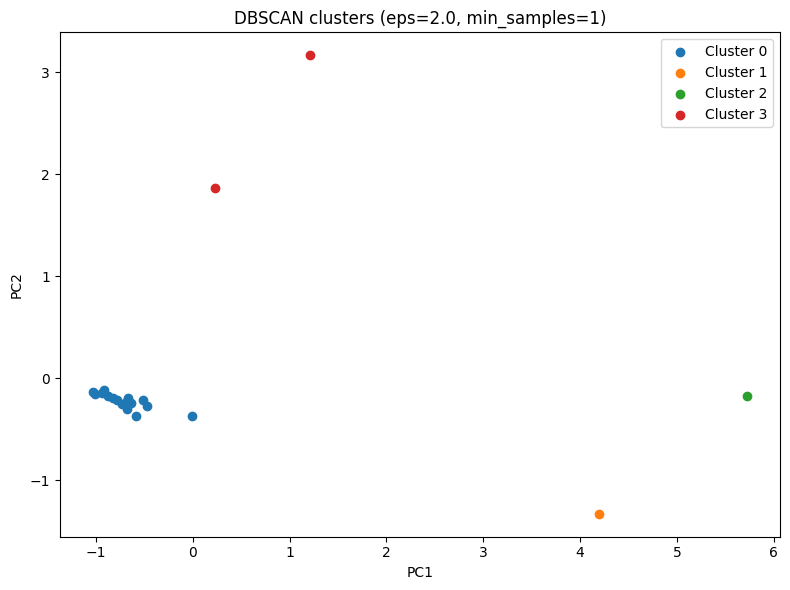

In [21]:
# PCA (DBSCAN)
pc_db = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
df_country[["PC1_DB", "PC2_DB"]] = pc_db

fig_db = px.scatter(
    df_country, x="PC1_DB", y="PC2_DB",
    color=df_country["Cluster_DB"].astype(str),
    hover_name=df_country.index,
    title=f"DBSCAN clusters (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})",
    template="plotly_white"
)
fig_db.show()
save_plotly(fig_db, "dbscan_scatter_interactive")

plt.figure(figsize=(8, 6))
for lbl in sorted(df_country["Cluster_DB"].unique()):
    m = df_country["Cluster_DB"] == lbl
    plt.scatter(df_country.loc[m, "PC1_DB"], df_country.loc[m, "PC2_DB"], label=f"Cluster {lbl}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"DBSCAN clusters (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})")
plt.legend(); plt.tight_layout()
save_matplotlib(plt.gcf(), "dbscan_scatter_static")
plt.show()

#### Radar Visualization

In [22]:
def plot_radar(
    centers: pd.DataFrame,
    feature_labels: List[str],
    title: str,
    scale_mode: str = "original",
    save_name: str | None = None,
) -> None:
    """
    Draw a radar chart using Plotly and optionally save it as HTML.
    Keeps the same function name and signature but now enforces
    the Matplotlib default palette for cluster colors.
    """
    # 1) Prepare the data
    df_plot = centers.copy()
    if scale_mode == "norm":
        df_plot = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min()).replace(0, np.nan)
        title_full = f"{title} (0–1 normalised)"
    else:
        title_full = title

    # 2) Get Matplotlib default colors and build Plotly figure
    mpl_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fig = go.Figure()
    for idx, (cluster_label, row) in enumerate(df_plot.iterrows()):
        color = mpl_colors[idx % len(mpl_colors)]
        values = row.tolist()
        # close the loop
        values += values[:1]
        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=feature_labels + [feature_labels[0]],
            name=f"Cluster {cluster_label}",
            fill="toself",
            opacity=0.4,
            line=dict(color=color, width=2),
            marker=dict(color=color)
        ))

    # 3) Update layout
    fig.update_layout(
        title=title_full,
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 1] if scale_mode=="norm" else None)
        ),
        showlegend=True,
        margin=dict(l=50, r=50, t=80, b=50),
    )

    # 4) Display in notebook
    fig.show()

    # 5) Save to HTML if requested
    if save_name:
        out_file = PLOT_DIR / f"{save_name}.html"
        fig.write_html(out_file, include_plotlyjs="cdn")
        print(f"[HTML] Saved radar chart to: {out_file.resolve().as_uri()}")

In [23]:
# Radar-scale mode: "original" | "norm" | "log"
RADAR_SCALE_MODE = "norm"

In [24]:
centers_db = (
    df_country.assign(**{
        feature: scaler.inverse_transform(df_country[scaled_cols])[:, idx]
        for idx, feature in enumerate(list(RAW_COLS.keys()))
    })
    .groupby("Cluster_DB")[list(RAW_COLS.keys())]
    .mean()
)
plot_radar(centers_db, [SHORT_LABELS[f] for f in RAW_COLS],
           title="DBSCAN Cluster profiles",
           scale_mode=RADAR_SCALE_MODE,
           save_name="radar_dbscan")

[HTML] Saved radar chart to: file:///content/gdrive/My%20Drive/BigDataProject/plots/radar_dbscan.html


#### Visualization Analysis


**Cluster 0**

**Representative Countries**: Argentina, Australia, Brazil, Canada, China

**Profile** (normalized 0–1)

* GHG/ha ≈ 0.7 (moderately high)
* Energy/ha ≈ 0.7 (moderately high)
* Pesticide/ha ≈ 0.7 (moderately high)
* Calories/ha ≈ 0.2 (low)

**Interpretation**
These nations have large-scale agricultural lands with moderate-to-high inputs of emissions, energy, and pesticides per hectare, yet produce relatively low caloric yield. This suggests a focus on raw materials or feed crops rather than high-calorie foodstuffs, leading to a “high input, low output” pattern with resource-intensive practices and suboptimal land productivity.

---

**Cluster 1**

**Representative Country**: Korea

**Profile**

* GHG/ha ≈ 0.7
* Energy/ha ≈ 0.7
* Pesticide/ha ≈ 1.0 (highest)
* Calories/ha ≈ 0.2

**Interpretation**
Korea exhibits peak pesticide use and high emissions and energy consumption, while caloric output remains modest. This cluster embodies “ultra‐intensive” modern agriculture: heavy chemical and mechanized inputs targeting yield or quality, but without commensurate gains in caloric efficiency, incurring high environmental costs.

---

**Cluster 2**

**Representative Country**: Japan

**Profile**

* GHG/ha ≈ 1.0 (highest)
* Energy/ha ≈ 1.0 (highest)
* Pesticide/ha ≈ 0.9
* Calories/ha ≈ 0.65 (moderate–low)

**Interpretation**
Japan’s agriculture invests maxicularly in emissions and energy, with very high pesticide use, yet achieves only moderate caloric yields. This indicates a tilt toward high‐value, low‐calorie crops (e.g., fruits, vegetables), emphasizing quality and environmental control rather than raw caloric output.

---

**Cluster 3**

**Representative Countries**: Norway, Switzerland

**Profile**

* GHG/ha ≈ 0.1 (very low)
* Energy/ha ≈ 0.15 (very low)
* Pesticide/ha ≈ 0.1 (very low)
* Calories/ha = 1.0 (highest)

**Interpretation**
This cluster exemplifies “low-input, high-output” agriculture: minimal reliance on fossil energy and agrochemicals, yet maximum caloric productivity. Factors likely include precision farming, greenhouse technology, optimized crop varieties, or exceptional natural conditions. It represents the most sustainable and resource‐efficient model.

---

**🔍 Summary Table**

| Cluster |       Input–Output Profile       | Representative Countries      | Sustainability Rating                          |
| :-----: | :------------------------------: | :---------------------------- | :--------------------------------------------- |
|    0    | Moderate–high inputs, low output | Argentina, Australia, Brazil… | Resource-intensive, moderate sustainability    |
|    1    |   Ultra–high inputs, mid output  | Korea                         | Intensive agriculture, high environmental cost |
|    2    |   High inputs, moderate output   | Japan                         | Precision agriculture, average efficiency      |
|    3    |      Low inputs, high output     | Norway, Switzerland           | Benchmark of sustainable, high efficiency      |


### K-means

In addition to DBSCAN algorithm above, we determine the optimal number of clusters via the elbow and silhouette methods, then apply the K-Means algorithm on the country-level feature matrix to assign each country a cluster label.

In [25]:
def choose_k(X: np.ndarray) -> Tuple[int, List[float], List[float]]:
    """Return best k plus silhouette & inertia curves for K-means."""
    sil_scores, inertias = [], []
    for k in range(K_MIN, K_MAX + 1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(X)
        sil_scores.append(silhouette_score(X, labels))
        inertias.append(km.inertia_)
    best_k = int(np.argmax(sil_scores) + K_MIN)
    return best_k, sil_scores, inertias

#### Perform clustering

In [26]:
best_k, sil_scores, inertias = choose_k(X)
print(f"[Info] Best k = {best_k} (silhouette = {sil_scores[best_k - K_MIN]:.3f})")
# Forced k
best_k = 4

[Info] Best k = 2 (silhouette = 0.797)


In [27]:
# Perform clustering and label data
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
df_country["Cluster_KM"] = km.fit_predict(X)
df["Cluster"] = df["Country"].map(df_country["Cluster_KM"])

To facilitate interpretation, we list the top N countries in each cluster based on their per-hectare efficiency scores, highlighting representative nations that exemplify each cluster’s profile.

In [28]:
# Top-N Countries
top_n_km = (
    df_country.reset_index()
    .groupby("Cluster_KM")["Country"]
    .apply(lambda s: s.head(TOP_N).tolist())
    .reset_index(name=f"Top{TOP_N}Countries_KM")
)
print(f"\n=== Top {TOP_N} countries in each K-means cluster ===")
print(top_n_km.to_string(index=False))


=== Top 5 countries in each K-means cluster ===
 Cluster_KM                                                     Top5Countries_KM
          0 [Argentina, Australia, Brazil, Canada, China (People’s Republic of)]
          1                                                              [Korea]
          2                                                              [Japan]
          3                                                [Norway, Switzerland]


It is clear that the country membership in each cluster is identical between K-means and DBSCAN, reinforcing the stability of these four groupings.

#### PCA Visualization

Similar to the DBSCAN Section, we perform PCA to reduce dimensions to two principal components and plot both an interactive Plotly scatter chart and a static Matplotlib version, coloring points by cluster membership.

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/kmeans_scatter_interactive.html
[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/kmeans_scatter_static.html


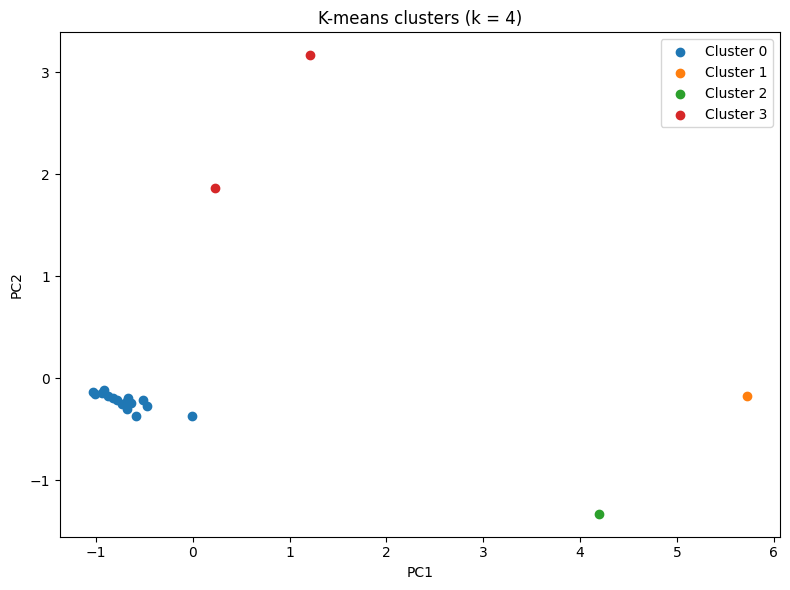

In [29]:
# PCA Visualization (K-Means)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pc = pca.fit_transform(X)
df_country[["PC1_KM", "PC2_KM"]] = pc

fig_km = px.scatter(
    df_country, x="PC1_KM", y="PC2_KM",
    color=df_country["Cluster_KM"].astype(str),
    hover_name=df_country.index,
    title=f"K-means clusters (k = {best_k})",
    template="plotly_white"
)
fig_km.show()
save_plotly(fig_km, "kmeans_scatter_interactive")

plt.figure(figsize=(8, 6))
for lbl in sorted(df_country["Cluster_KM"].unique()):
    m = df_country["Cluster_KM"] == lbl
    plt.scatter(df_country.loc[m, "PC1_KM"], df_country.loc[m, "PC2_KM"], label=f"Cluster {lbl}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-means clusters (k = {best_k})")
plt.legend(); plt.tight_layout()
save_matplotlib(plt.gcf(), "kmeans_scatter_static")
plt.show()

#### Diagnostic Visualization

Here we plot the silhouette scores and inertia (WCSS) curves across different k values to validate the chosen cluster number, ensuring the clustering structure is both distinct and stable.

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/silhouette_curve.html


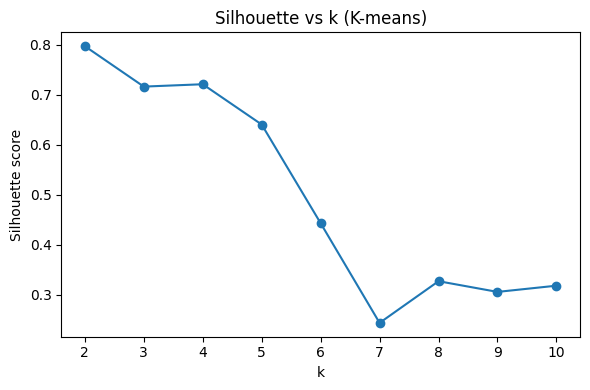

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/elbow_plot.html


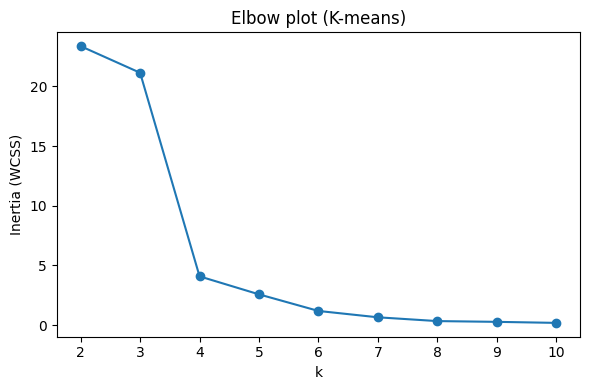

In [30]:
# Diagnostic curves
plt.figure(figsize=(6, 4))
plt.plot(range(K_MIN, K_MAX+1), sil_scores, marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (K-means)"); plt.tight_layout()
save_matplotlib(plt.gcf(), "silhouette_curve")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(K_MIN, K_MAX+1), inertias, marker="o")
plt.xlabel("k"); plt.ylabel("Inertia (WCSS)")
plt.title("Elbow plot (K-means)"); plt.tight_layout()
save_matplotlib(plt.gcf(), "elbow_plot")
plt.show()

The Silhouette Score is a metric for evaluating clustering quality by measuring how similar an object is to its own cluster compared to other clusters. For a sample $i$, define:

* $a_i$: average distance between $i$ and all other points in its own cluster (intra-cluster distance).
* $b_i$: minimum average distance between $i$ and all points in any other cluster (nearest-cluster distance).

The silhouette score for sample $i$ is:

$$
s_i = \frac{b_i - a_i}{\max(a_i,\,b_i)}
$$

* Range: $-1 \le s_i \le 1$.

  * Close to +1: well-clustered, cohesive within its cluster and well-separated from others.
  * Around 0: on or near a cluster boundary.
  * Close to -1: misclassified, better suited to another cluster.

Based on the Elbow Plot and Silhouette Score PLot above, it is obvious that:

* **Elbow Plot** shows inertia sharply dropping from k=2→3→4, then leveling off after k=4–5, indicating the “elbow” around k=4.
* **Silhouette Curve** peaks at k=2 (\~0.79), then drops to \~0.72 for k=3 and k=4. Although k=2 has the highest average silhouette, k=4 offers finer granularity with still good cohesion and separation.

In this case, balancing cluster compactness and interpretability, the choosen k value, k=4 is the optimal compromise.



#### Radar Visualization

In [31]:
# Invert the scaler to get raw per-ha centers for K-Means
orig_centers = scaler.inverse_transform(km.cluster_centers_)
centers_km = pd.DataFrame(
    orig_centers,
    columns=list(RAW_COLS.keys()),
    index=[f"Cluster {i}" for i in range(best_k)]
)

# Call the unified Plotly-based radar function with matching Matplotlib palette
plot_radar(
    centers_km,
    [SHORT_LABELS[f] for f in RAW_COLS],
    title="K-means Cluster profiles",
    scale_mode=RADAR_SCALE_MODE,   # e.g. "norm" or "original"
    save_name="radar_kmeans"
)
print(f"\n=== Top {TOP_N} countries in each K-means cluster ===")
print(top_n_km.to_string(index=False))

[HTML] Saved radar chart to: file:///content/gdrive/My%20Drive/BigDataProject/plots/radar_kmeans.html

=== Top 5 countries in each K-means cluster ===
 Cluster_KM                                                     Top5Countries_KM
          0 [Argentina, Australia, Brazil, Canada, China (People’s Republic of)]
          1                                                              [Korea]
          2                                                              [Japan]
          3                                                [Norway, Switzerland]


#### Visualization Analysis

When compared with the DBSCAN clustering results, the sole distinction lies in the label assignments: K-means designated Cluster 1 and 2 as Korea and Japan respectively, whereas DBSCAN assigned Japan and Korea to the corresponding clusters.

This constitutes a label switch between the two methodologies, while the classification outcomes are identical except for the cluster label designations. We therefore conclude that both clustering algorithms produce equivalent (similar) results.

Both algorithms identify Cluster 3 (red) as the “low-input, high-output” archetype with minimal emissions/energy/pesticide inputs and maximal caloric yield.

To be more specific:

 - In Cluster 1 (orange), K-means pushes GHG/ha and Energy/ha to the normalized maximum (1.0), whereas DBSCAN places them slightly lower (\~0.8–0.9), indicating K-means’ sensitivity to extreme input outliers.

 - Clusters 0 (blue) and 2 (green) exhibit nearly identical shapes across both methods, affirming the robustness of the “moderate-input, moderate-output” patterns.

## Interpretation

### Clusrtering Analysis

According to the resultes and visulization of K-means and DBSCAN Clusters above, we can find out that:

* Both algorithms consistently classify Norway/Switzerland as the “best practice” low-input/high-output cluster, Korea as the “ultra‐intensive” cluster, Argentina… as the “moderate-input/low-output” group, and Japan as “high-input/moderate-output.”
* **Strategic Alignment**: The high agreement between K-means and DBSCAN confirms that the previously recommended precision-agriculture, environmental governance, output-enhancement, and exemplar-diffusion strategies remain valid and robust across clustering methods.


To be more specific:





**Cluster 0 – Optimize Input Structure, Improve Land Productivity**

* **Issue**: Low resource‐use efficiency: moderate-high emissions, energy, and pesticide inputs but low caloric output per hectare.
* **Recommendations**:

  1. **Precision Agriculture**: Adopt remote sensing, variable‐rate fertilization, and smart irrigation to tailor inputs and minimize waste.
  2. **Variety & Crop Rotation**: Introduce high-yield, stress-tolerant crop varieties and optimize rotation/intercropping to enrich soil and boost yields.
  3. **Incentive Reform**: Shift subsidies from area-based to output/efficiency-based, motivating farmers to maximize per-hectare yield rather than expanding acreage.

**Cluster 1 – Control Externalities, Enhance Environmental Governance**

* **Issue**: Extremely high inputs per hectare, leading to significant pesticide use and emissions with heavy environmental costs.
* **Recommendations**:

  1. **Resource Intensity Audits**: Implement emission-and-pesticide audits by region, setting upper limits on resource use in high-intensity areas.
  2. **Green Substitutes**: Promote biopesticides, drip/micro-sprinkler irrigation, and solar-powered greenhouses to reduce reliance on fossil fuels.
  3. **Environmental Credit Mechanisms**: Issue carbon credits or “green certificates” to farms that reduce per-unit inputs or emissions, incentivizing sustainable practices.


**Cluster 2 – Enhance Output Capacity, Drive Efficiency Reform**

* **Issue**: Careful input management but insufficient caloric output, indicating suboptimal land productivity.
* **Recommendations**:

  1. **High-Value Crops**: Encourage mixed cropping of caloric staples with higher-value crops to balance caloric and economic returns.
  2. **Smart Controlled-Environment Agriculture**: Support vertical farms and smart greenhouses to boost yields per square meter and reduce land footprint.
  3. **Branding & Certification**: Develop geo-indication and organic/green certifications to command product premiums and improve per-unit value.



**Cluster 3 – Scale Up as Sustainable Exemplars**

* **Issue**: No major shortcomings; represents a “low-input, high-output” best practice.
* **Recommendations**:

  1. **Experience Sharing**: Showcase their subsidy frameworks, technology adoption, and standards in international forums and bilateral partnerships.
  2. **Knowledge Transfer**: Establish joint sustainable‐agriculture demo zones with Cluster 0/1 countries for training and tech export.
  3. **Demonstration Pilots**: Deploy pilot projects in developing regions to replicate their precision and green management models, creating scalable institutional templates.

### Time Series Analysis

 In this part, we plot the temporal trends of efficiency and sustainability scores for each cluster, evaluating long-term improvements or regressions in resource use over time.

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/paired_cluster_trends.html


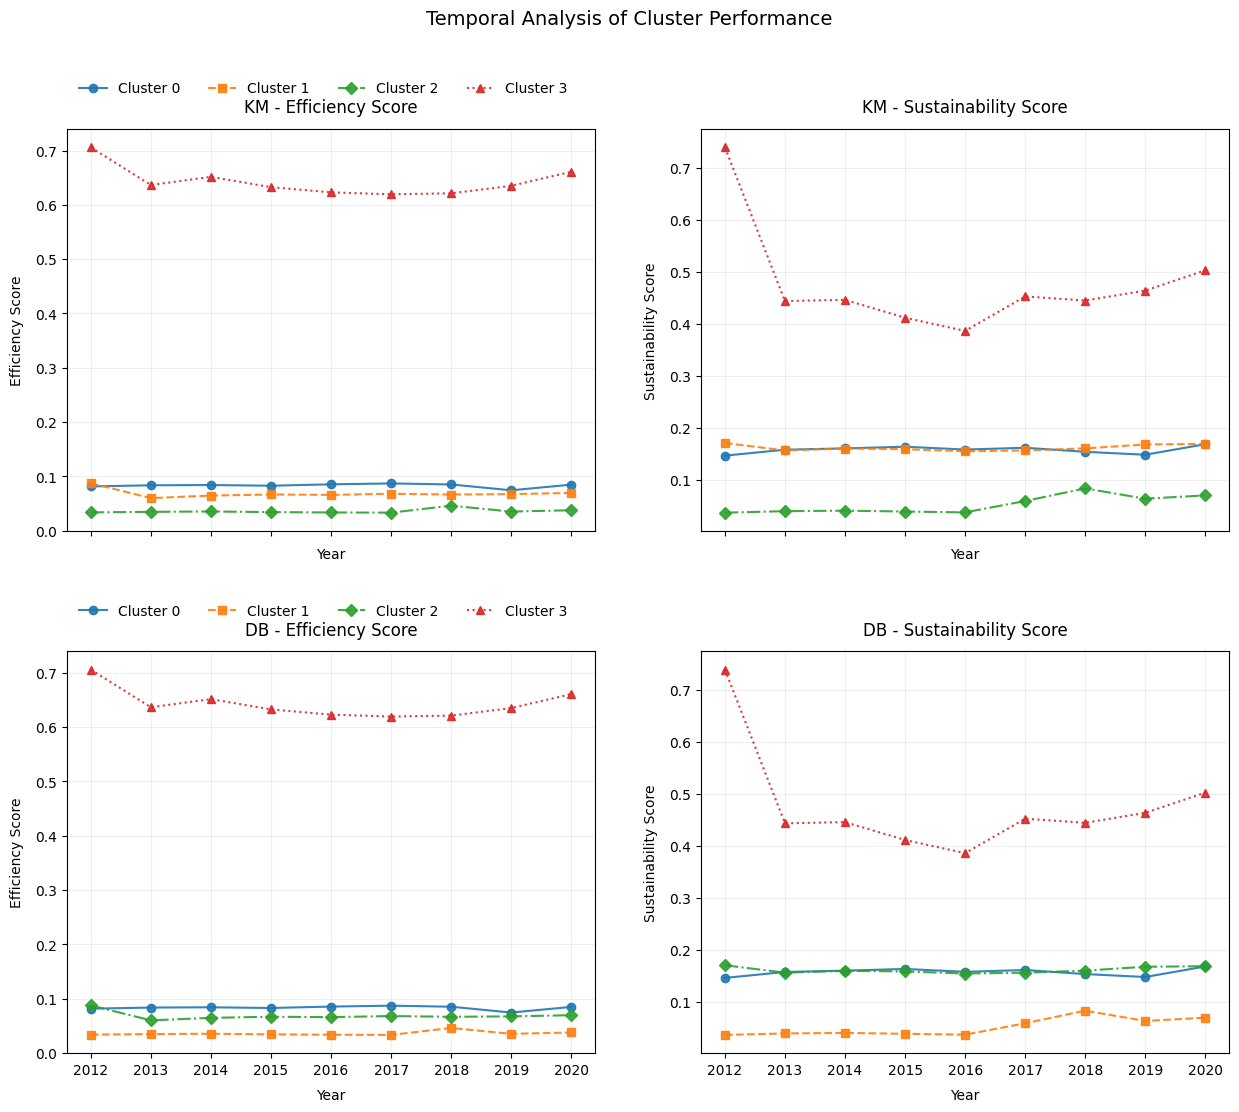

In [32]:
REQUIRED = {"Year", "efficiency score", "sustainability score"}
if REQUIRED.issubset(df.columns):
    df_time = (
        df[["Country", "Year", "efficiency score", "sustainability score"]]
        .merge(df_country[["Cluster_KM", "Cluster_DB"]], left_on="Country", right_index=True)
        .dropna(subset=["Year"])
    )
    df_time["Year"] = df_time["Year"].astype(int)
    agg = (
        df_time.groupby(["Year", "Cluster_KM", "Cluster_DB"])[["efficiency score", "sustainability score"]]
        .mean().reset_index()
    )

    # Create figure with 2 rows (KM and DB) and 2 columns (metrics)
    fig, axs = plt.subplots(2, 2, figsize=(15, 12), sharex=True)
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # Configure plot styling
    metric_names = ["Efficiency Score", "Sustainability Score"]
    line_styles = ['-o', '--s', '-.D', ':^']  # Distinct markers for clusters
    cluster_colors = plt.cm.tab10.colors  # Standard color palette

    # Generate paired plots
    for method_idx, method in enumerate(["KM", "DB"]):
        method_prefix = f"Cluster_{method}"
        clusters = sorted(agg[method_prefix].unique())

        for metric_idx, metric in enumerate(["efficiency score", "sustainability score"]):
            ax = axs[method_idx, metric_idx]

            # Plot each cluster's trend
            for cluster_idx, cluster in enumerate(clusters):
                cluster_data = agg[agg[method_prefix] == cluster]
                ax.plot(cluster_data["Year"], cluster_data[metric],
                        line_styles[cluster_idx % len(line_styles)],
                        color=cluster_colors[cluster_idx],
                        label=f'Cluster {cluster}',
                        alpha=0.9)

            # Configure subplot
            ax.set_title(f"{method} - {metric_names[metric_idx]}", pad=12)
            ax.set_xlabel("Year", labelpad=8)
            ax.set_ylabel(metric_names[metric_idx], labelpad=8)
            ax.grid(True, alpha=0.2)

            # Only add legend to first column
            if metric_idx == 0:
                ax.legend(loc='upper left', bbox_to_anchor=(0, 1.15),
                        ncol=len(clusters), frameon=False)

    # Global figure settings
    plt.suptitle("Temporal Analysis of Cluster Performance", y=0.98, fontsize=14)

    # Save and display
    save_matplotlib(fig, "paired_cluster_trends")
    plt.show()
else:
    miss = REQUIRED - set(df.columns)
    print(f"[Warning] Missing columns {miss}, temporal analysis skipped.")

In this section, we shift focus from exact annual values to the **distinct dynamic behaviors** of the four clusters—using the Efficiency and Sustainability scores defined in Question 1 (Part 1)—thereby demonstrating the **superiority and practical relevance** of our clustering.

1. **Contrast Between Cluster 1 and Cluster 3 Is Most Striking**

   * **Cluster 1 (Ultra-Intensive, Mid-Output)** shows a pronounced “V-shaped” trajectory: between 2012–2016, high-input regions (e.g., Korea) sharply curtailed energy and pesticide use—dropping both efficiency and sustainability scores—to address environmental pressures; then in 2017–2018, targeted policy and technology measures sparked a synchronized rebound.
   * **Cluster 3 (Low-Input, High-Output)** remains robust: despite a mid-period dip (likely from system upgrades or external shocks), it quickly recovers and sustains peak efficiency and sustainability, highlighting its resilience and “best-practice” advantages.

2. **Clusters 0 and 2 Serve as Stable Midpoints**

   * **Cluster 0 (Moderate-Input, Moderate-Output)** and **Cluster 2 (High-Input, Low-Output)** maintain their respective mid-range trajectories throughout the period—Cluster 0 with slight gains, Cluster 2 with minor fluctuations—validating the clustering’s distinction of two intermediate agricultural regimes.

3. **Importance of Time Trends**

   * Time-series analysis confirms that our clusters not only separate clearly in static profiles (radar charts) but also exhibit **unique temporal signatures**: Cluster 1’s self-correction, Cluster 3’s sustained leadership, and the steady states of Clusters 0/2 form a cohesive, multidimensional understanding of agricultural resource efficiency.

4. **Methodological Consistency and Cohesive Conclusions**

   * From the weighted score definitions in Part 1 to the temporal trend validation here, both K-means and DBSCAN reproduce the same four-cluster structure and dynamic patterns, demonstrating that our multi-method approach yields **consistent conclusions** across static and dynamic perspectives.



## Packaging

In [33]:
class AgricultureClusterAnalyzer:
    def __init__(self, data_path: Path, forced_k: int | None = None):
        self.data_path = data_path
        self.forced_k = forced_k
        self.df = None
        self.df_country = None
        self.scaled_cols = None
        self.scaler = None
        self.best_k = None
        self.sil_scores = None
        self.inertias = None

    def prepare_data(self):
        # 0) Read CSV and fix column names
        df0 = pd.read_csv(self.data_path)
        df0.columns = [c.replace("_", " ") for c in df0.columns]
        df0.to_csv(self.data_path, index=False)
        # 1) Derive metrics, handle missing values, normalization
        self.df, self.scaled_cols, self.scaler = load_and_prepare()

    def aggregate(self):
        # Aggregate by country
        self.df_country = self.df.groupby("Country")[self.scaled_cols].mean()
        return self.df_country.values

    def run_kmeans(self):
        # Select k
        X = self.aggregate()
        self.best_k, self.sil_scores, self.inertias = choose_k(X)
        if self.forced_k is not None:
            self.best_k = self.forced_k
        print(f"[Info] Best k = {self.best_k} (silhouette = {self.sil_scores[self.best_k - K_MIN]:.3f})")

        # Perform clustering and label data
        km = KMeans(n_clusters=self.best_k, random_state=RANDOM_STATE, n_init="auto")
        labels = km.fit_predict(X)
        self.df_country["Cluster_KM"] = labels

        # Map country → cluster back onto the full df
        map_km = dict(zip(self.df_country.index, labels))
        self.df["Cluster_KM"] = self.df["Country"].map(map_km)

        # PCA dimensionality reduction
        pc = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
        self.df_country[["PC1_KM", "PC2_KM"]] = pc

    def run_dbscan(self):
        # Use the already-aggregated self.df_country
        X = self.df_country[self.scaled_cols].values
        db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
        labels = db.fit_predict(X)

        self.df_country["Cluster_DB"] = labels
        map_db = dict(zip(self.df_country.index, labels))
        self.df["Cluster_DB"] = self.df["Country"].map(map_db)

        # PCA dimensionality reduction
        pc_db = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
        self.df_country[["PC1_DB", "PC2_DB"]] = pc_db

    def plot_diagnostics(self):
        # Ensure that DBSCAN labels exist
        if "Cluster_DB" not in self.df_country.columns:
            print("[Info] Cluster_DB not found, automatically calling run_dbscan()")
            self.run_dbscan()

        # 1) K-Means interactive scatter
        fig_km = px.scatter(
            self.df_country,
            x="PC1_KM",
            y="PC2_KM",
            color=self.df_country["Cluster_KM"].astype(str),
            hover_name=self.df_country.index,
            title=f"K-means clusters (k = {self.best_k})",
            template="plotly_white"
        )
        fig_km.show()
        save_plotly(fig_km, "kmeans_scatter_interactive")

        # 2) K-Means static scatter
        plt.figure(figsize=(8, 6))
        for lbl in sorted(self.df_country["Cluster_KM"].unique()):
            mask = self.df_country["Cluster_KM"] == lbl
            plt.scatter(
                self.df_country.loc[mask, "PC1_KM"],
                self.df_country.loc[mask, "PC2_KM"],
                label=f"Cluster {lbl}"
            )
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"K-means clusters (k = {self.best_k})")
        plt.legend()
        plt.tight_layout()
        save_matplotlib(plt.gcf(), "kmeans_scatter_static")
        plt.show()

        # 3) Diagnostic curves
        plt.figure()
        plt.plot(range(K_MIN, K_MAX + 1), self.sil_scores, marker="o")
        plt.title("Silhouette vs k")
        save_matplotlib(plt.gcf(), "silhouette_curve")
        plt.show()

        plt.figure()
        plt.plot(range(K_MIN, K_MAX + 1), self.inertias, marker="o")
        plt.title("Elbow plot")
        save_matplotlib(plt.gcf(), "elbow_plot")
        plt.show()

        # 4) Top-N countries per K-Means cluster
        top_n_km = (
            self.df_country.reset_index()
            .groupby("Cluster_KM")["Country"]
            .apply(lambda s: s.head(TOP_N).tolist())
        )
        print(f"=== Top {TOP_N} countries in each K-means cluster ===\n{top_n_km}")

        # 5) Radar chart for K-Means
        #    compute raw centers in original units
        km_model = KMeans(n_clusters=self.best_k, random_state=RANDOM_STATE, n_init="auto")
        raw_centers = km_model.fit(self.df_country[self.scaled_cols].values).cluster_centers_
        orig_centers_km = self.scaler.inverse_transform(raw_centers)
        df_centers_km = pd.DataFrame(
            orig_centers_km,
            columns=list(RAW_COLS.keys()),
            index=[f"Cluster {i}" for i in range(self.best_k)]
        )
        #    now call our Plotly radar subroutine with correct flag
        self._plot_radar_plotly(
            df_centers_km,
            [SHORT_LABELS[f] for f in RAW_COLS],
            "K-means Cluster profiles",
            norm=(RADAR_SCALE_MODE == "norm"),
            save_name="radar_kmeans"
        )

        # 6) DBSCAN interactive scatter
        fig_db = px.scatter(
            self.df_country,
            x="PC1_DB",
            y="PC2_DB",
            color=self.df_country["Cluster_DB"].astype(str),
            hover_name=self.df_country.index,
            title=f"DBSCAN clusters (eps={DBSCAN_EPS})",
            template="plotly_white"
        )
        fig_db.show()
        save_plotly(fig_db, "dbscan_scatter_interactive")

        # 7) DBSCAN static scatter
        plt.figure(figsize=(8, 6))
        for lbl in sorted(self.df_country["Cluster_DB"].unique()):
            mask = self.df_country["Cluster_DB"] == lbl
            plt.scatter(
                self.df_country.loc[mask, "PC1_DB"],
                self.df_country.loc[mask, "PC2_DB"],
                label=f"Cluster {lbl}"
            )
        plt.title("DBSCAN clusters")
        plt.legend()
        plt.tight_layout()
        save_matplotlib(plt.gcf(), "dbscan_scatter_static")
        plt.show()

        # 8) Radar chart for DBSCAN
        #    first invert-scaled back into original units
        df_unscaled = pd.DataFrame(
            self.scaler.inverse_transform(self.df_country[self.scaled_cols].values),
            columns=list(RAW_COLS.keys()),
            index=self.df_country.index
        )
        df_centers_db = (
            df_unscaled
            .assign(Cluster_DB=self.df_country["Cluster_DB"])
            .groupby("Cluster_DB")[list(RAW_COLS.keys())]
            .mean()
        )
        self._plot_radar_plotly(
            df_centers_db,
            [SHORT_LABELS[f] for f in RAW_COLS],
            "DBSCAN Cluster profiles",
            norm=(RADAR_SCALE_MODE == "norm"),
            save_name="radar_dbscan"
        )

    def _plot_radar_plotly(
        self,
        centers: pd.DataFrame,
        feature_labels: List[str],
        title: str,
        norm: bool = False,
        save_name: str | None = None
    ) -> None:
        """Draw a radar chart using Plotly and optionally save it as HTML."""
        # 1) Prepare data
        df_plot = centers.copy()
        if norm:
            df_plot = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min()).replace(0, np.nan)
            title_full = f"{title} (0–1 normalised)"
        else:
            title_full = title

        # 2) Define a fixed 4-color sequence (matplotlib default palette)
        colors = [
            "rgba(31,119,180,0.4)",   # blue
            "rgba(255,127,14,0.4)",   # orange
            "rgba(44,160,44,0.4)",    # green
            "rgba(214,39,40,0.4)"     # red
        ]
        line_colors = [
            "rgb(31,119,180)",
            "rgb(255,127,14)",
            "rgb(44,160,44)",
            "rgb(214,39,40)"
        ]

        # 3) Build the figure
        fig = go.Figure()
        for idx, (cluster_label, row) in enumerate(df_plot.iterrows()):
            vals = row.tolist()
            vals += vals[:1]
            fig.add_trace(go.Scatterpolar(
                r=vals,
                theta=feature_labels + [feature_labels[0]],
                name=f"Cluster {cluster_label}",
                fill="toself",
                fillcolor=colors[idx],
                line=dict(color=line_colors[idx], width=2),
                opacity=0.7
            ))

        # 4) Layout
        fig.update_layout(
            title=title_full,
            polar=dict(
                radialaxis=dict(visible=True, range=[0,1] if norm else None)
            ),
            showlegend=True,
            margin=dict(l=50, r=50, t=80, b=50),
        )

        # 5) Render & save
        fig.show()
        if save_name:
            out = PLOT_DIR / f"{save_name}.html"
            fig.write_html(out, include_plotlyjs="cdn")
            print(f"[HTML] Saved radar chart to: {out.resolve().as_uri()}")

    def temporal_analysis(self):
        required = {"Year", "efficiency score", "sustainability score"}
        if required.issubset(self.df.columns):
            df_t = (self.df[["Country","Year","efficiency score","sustainability score"]]
                    .merge(self.df_country[["Cluster_KM","Cluster_DB"]], left_on="Country", right_index=True)
                    .dropna(subset=["Year"]))
            df_t["Year"] = df_t["Year"].astype(int)
            agg = df_t.groupby(["Year","Cluster_KM","Cluster_DB"])[["efficiency score","sustainability score"]].mean().reset_index()
            for method in ("KM","DB"):
                for metric in ("efficiency score","sustainability score"):
                    plt.figure()
                    for c in sorted(agg[f"Cluster_{method}"].unique()):
                        ser = agg[agg[f"Cluster_{method}"]==c].set_index("Year")[metric]
                        plt.plot(ser.index, ser.values, marker="o", label=f"Cluster {c}")
                    plt.title(f"{metric} trend by {method}"); plt.tight_layout()
                    save_matplotlib(plt.gcf(), f"trend_{method}_{metric}"); plt.show()
        else:
            miss = required - set(self.df.columns)
            print(f"[Warning] Missing columns {miss}, skipping temporal analysis")

    def save_results(self):
        # Export the final df with cluster labels
        self.df.to_csv("scores_with_clusters.csv", index=False)


### Test the Packaged Class

[Info] Best k = 4 (silhouette = 0.721)


[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/kmeans_scatter_interactive.html
[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/kmeans_scatter_static.html


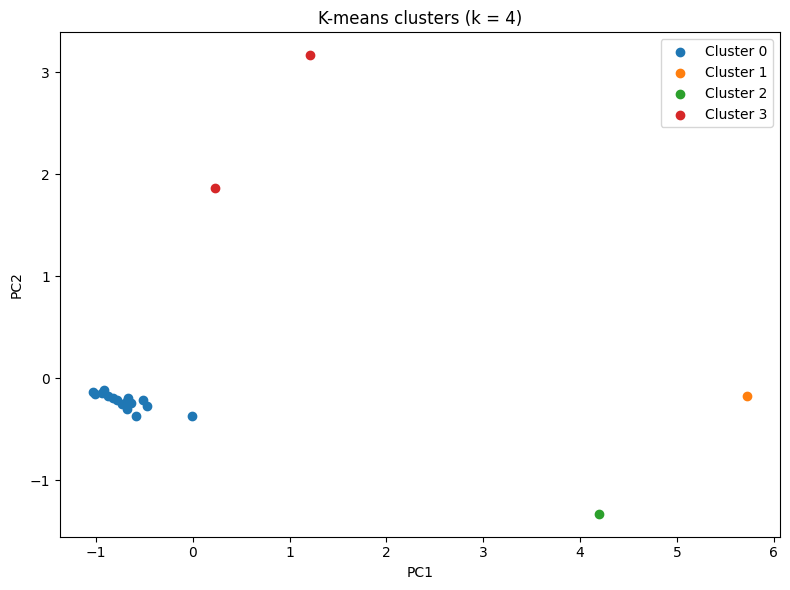

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/silhouette_curve.html


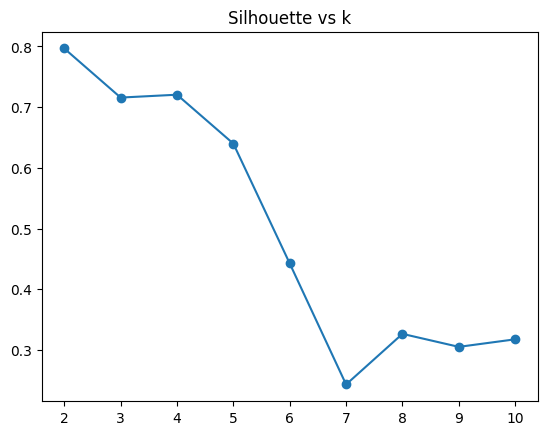

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/elbow_plot.html


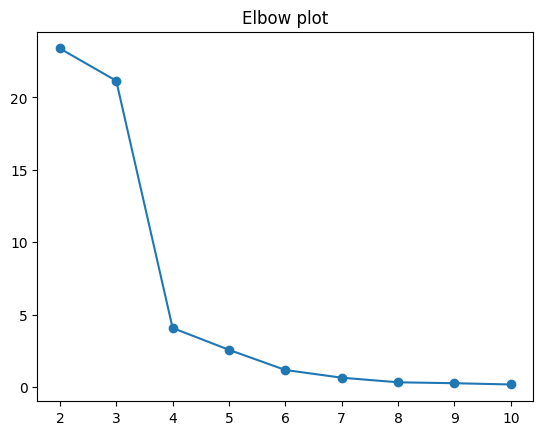

=== Top 5 countries in each K-means cluster ===
Cluster_KM
0    [Argentina, Australia, Brazil, Canada, China (...
1                                              [Korea]
2                                              [Japan]
3                                [Norway, Switzerland]
Name: Country, dtype: object


[HTML] Saved radar chart to: file:///content/gdrive/My%20Drive/BigDataProject/plots/radar_kmeans.html


[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/dbscan_scatter_interactive.html
[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/dbscan_scatter_static.html


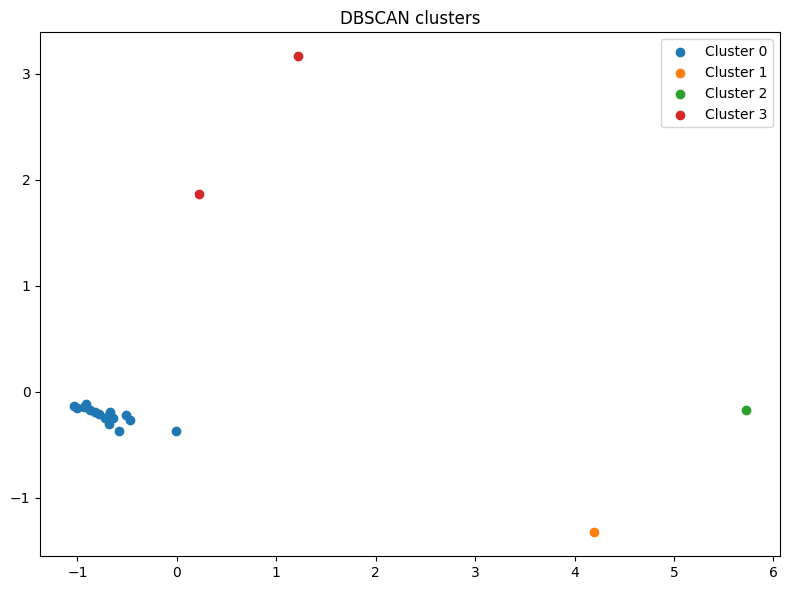

[HTML] Saved radar chart to: file:///content/gdrive/My%20Drive/BigDataProject/plots/radar_dbscan.html
[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/trend_KM_efficiency_score.html


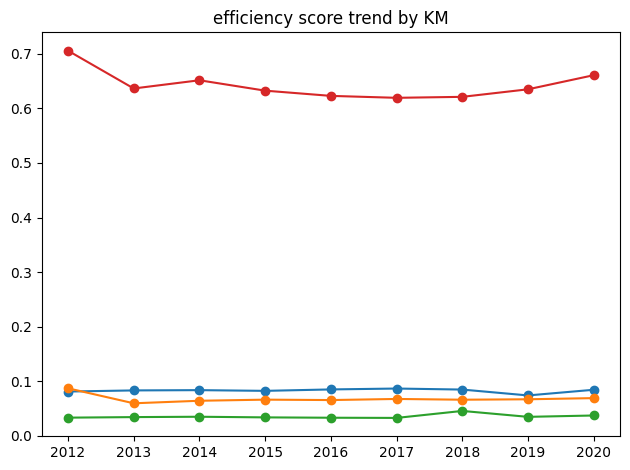

[HTML] file:///content/gdrive/My%20Drive/BigDataProject/plots/trend_KM_sustainability_score.html


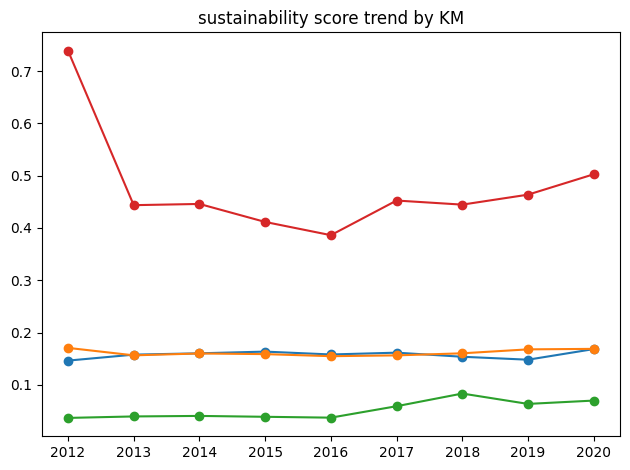

[HTML] file:///content/gdrive/MyDrive/BigDataProject/plots/trend_DB_efficiency_score.html


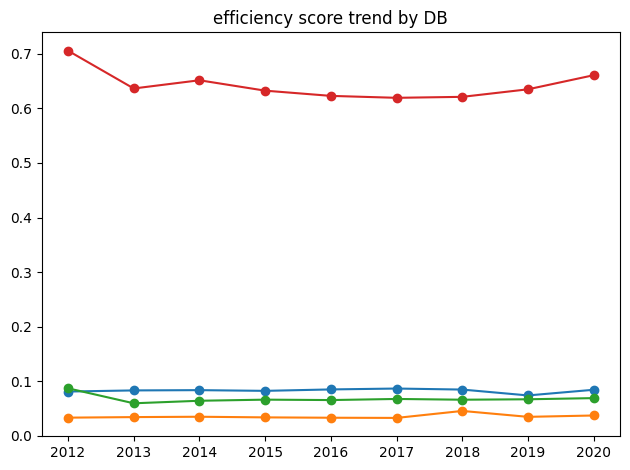

[HTML] file:///content/gdrive/MyDrive/BigDataProject/plots/trend_DB_sustainability_score.html


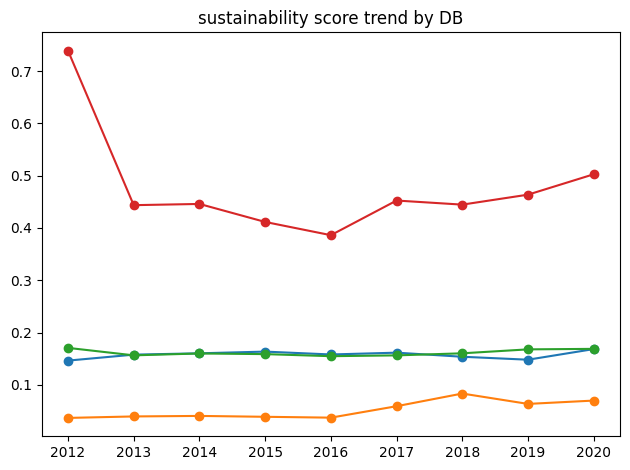

In [34]:
analyzer = AgricultureClusterAnalyzer(DATA_PATH, forced_k=4)
analyzer.prepare_data()
analyzer.run_kmeans()
analyzer.run_dbscan()
analyzer.plot_diagnostics()
analyzer.temporal_analysis()
analyzer.save_results()

The outputs from the cell above are solely intended to demonstrate the effectiveness of our encapsulated operations, therefore no analysis was performed on these outputs themselves. The full analysis of these output results is comprehensively presented in the Cluster and Interpretation sections.

## General Visualization

### Load Clustered Data

In [35]:
data = pd.read_csv("scores_with_clusters.csv")

ghg_col = 'Total greenhouse gas emissions by gas (without LULUCF) (Tonnes of CO2-equivalent)'
pesticide_col = 'Total sales of agricultural pesticides (Tonnes)'
calorie_col = 'Total calorie availability (Kilocalories per person per day)'
land_col = 'Total agricultural land area (Hectares)'
energy_col = 'Direct on-farm energy consumption (Tonnes of oil equivalent)'

data['ghg per hectare'] = data[ghg_col] / data[land_col]
data['pesticide per hectare'] = data[pesticide_col] / data[land_col]
data['calorie pct per hectare'] = data[calorie_col] / data[land_col]
data['energy per hectare'] = data[energy_col] / data[land_col]

cols_to_round = ['ghg per hectare', 'pesticide per hectare', 'calorie pct per hectare', 'energy per hectare']
data[cols_to_round] = data[cols_to_round].round(2)


# View the result
data[['Country', 'Year', 'ghg per hectare', 'pesticide per hectare', 'calorie pct per hectare']].head()

,Country,Year,ghg per hectare,pesticide per hectare,calorie pct per hectare
0,Argentina,2012,2.49,2.05,0.02
1,Argentina,2013,2.61,2.22,0.02
2,Argentina,2014,2.69,2.35,0.03
3,Argentina,2015,4.40,2.24,0.03
4,Argentina,2016,4.52,2.21,0.03


### Country Name Process

In this section, we standardize the `Country` column by mapping each nation’s name to its ISO 3166-1 alpha-3 code, ensuring accurate geographic visualization later on. The workflow is:

1. **Automated Lookup**: Use `pycountry.countries.lookup(name).alpha_3` to convert recognized country names directly into three-letter codes.
2. **Manual Corrections**: For non-standard or ambiguous names (e.g., `"China (People’s Republic of)"` → `"China"`, `"Korea"` → `"South Korea"`), we define a `manual_map` dictionary and replace these entries before lookup.
3. **Second Pass Matching**: Apply the automated lookup again on the cleaned `country_clean` column to capture any names missed initially.
4. **Integrity Check**: Print out any `unmatched` countries to verify that all rows have been successfully mapped.

After these steps, the new `iso_alpha` column contains valid ISO3 codes for all countries, enabling precise mapping in subsequent visualizations.

In [36]:
def get_iso3_code(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

# Add ISO3 country code column
data['iso_alpha'] = data['Country'].apply(get_iso3_code)

# Manual corrections for non-standard country names
manual_map = {
    'China (People’s Republic of)': 'China',
    'Developed countries': None,
    'Developing countries': None,
    'Flemish Region': 'Belgium',
    'Wallonia': 'Belgium',
    'Korea': 'South Korea',
    'Russia': 'Russian Federation'
}

data['country_clean'] = data['Country'].replace(manual_map)
data['iso_alpha'] = data['country_clean'].apply(get_iso3_code)

unmatched = data[data['iso_alpha'].isnull()]
print("Unmatched countries:", unmatched['Country'].unique())

Unmatched countries: []


It shows that all country names are matched.

### Visualization

In [40]:
app = dash.Dash(__name__)

# Store information for currently selected country
current_data = {
    'performance_box': "",
    'graph': "",
    'table': ""
}

# Data processing
cluster_map = data.groupby('Country')['Cluster_KM'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown').reset_index()
map_data = data.groupby('Country', as_index=False)['ghg per hectare'].mean()
map_data = map_data.merge(cluster_map, on='Country', how='left')
map_data['Cluster_KM'] = map_data['Cluster_KM'].astype(str)

# Calculate global average/median for various metrics
cluster_scores = data.groupby('Cluster_KM')[['efficiency score','sustainability score']].mean().reset_index()
cluster_scores['Cluster_KM'] = cluster_scores['Cluster_KM'].astype(str)

efficiency_global_median = data['efficiency score'].median()
sustainability_global_median = data['sustainability score'].median()
ghg_global_mean = data['ghg per hectare'].mean()
energy_global_mean = data['Direct on-farm energy consumption (Tonnes of oil equivalent)'].mean()

# Calculate global average by year
global_energy_avg_by_year = data.groupby('Year')['Direct on-farm energy consumption (Tonnes of oil equivalent)'].mean()
global_ghg_avg_by_year = data.groupby('Year')['ghg per hectare'].mean()
global_efficiency_median_by_year = data.groupby('Year')['efficiency score'].median()
global_sustainability_median_by_year = data.groupby('Year')['sustainability score'].median()

# Mark cluster performance
cluster_scores['efficiency_mark'] = np.where(
    cluster_scores['efficiency score'] > efficiency_global_median, '✔', '✘'
)
cluster_scores['sustainability_mark'] = np.where(
    cluster_scores['sustainability score'] > sustainability_global_median, '✔', '✘'
)

# Merge data
map_data = map_data.drop(columns=['efficiency score','sustainability score'], errors='ignore')
map_data = map_data.merge(
    cluster_scores[['Cluster_KM', 'efficiency score','sustainability score', 'efficiency_mark','sustainability_mark']],
    on='Cluster_KM', how='left'
)

# Create world map
fig_map = px.choropleth(
    data_frame=map_data,
    locations='Country',
    locationmode='country names',
    color='Cluster_KM',
    color_discrete_sequence=px.colors.qualitative.Set3,
    hover_name='Country',
    custom_data=['Cluster_KM', 'efficiency_mark', 'efficiency score',
                'sustainability_mark','sustainability score']
)

fig_map.update_traces(
    hovertemplate="""
        <span style="font-size:18px; font-weight:700; color:#e0e7ff;">%{location}</span><br><br>
        <span style="font-size:16px; font-weight:600; color:#d0d4db;"><b>Cluster:</b> %{customdata[0]}</span><br>
        <span style="font-size:15px; font-weight:700; text-decoration: underline; color:#a0b9ff; margin-top:6px; display:block;">Cluster Average Scores:</span><br>
        <span style="color:#7fff7f; font-weight:700;">%{customdata[1]} Efficiency:</span> <span style="font-weight:600; color:#ccffcc;">%{customdata[2]:.2f}</span><br>
        <span style="color:#ff7f7f; font-weight:700;">%{customdata[3]} Sustainability:</span> <span style="font-weight:600; color:#ffcccc;">%{customdata[4]:.2f}</span>
    <extra></extra>
    """
)

fig_map.update_geos(
    showcountries=True,
    countrycolor="black",
    showcoastlines=False,
    showframe=False
)

# App layout
app.layout = html.Div([
    dcc.Graph(id='world-map', figure=fig_map, style={'width': '100%', 'height': '700px'}),
    html.Button("Show/Hide Details", id="toggle-button", n_clicks=0, style={'display': 'none','margin': '10px 0'}),
    html.Div(id='performance-box', style={
        'border': '2px solid #333',
        'borderRadius': '8px',
        'padding': '15px',
       'margin': '20px 0',
        'width': '400px',
        'backgroundColor': '#f9f9f9'
    }),
    html.Div(id='country-details', style={'display': 'none'}),
])

# Callback function
@app.callback(
    Output('performance-box', 'children'),
    Output('toggle-button', 'style'),
    Output('country-details', 'children'),
    Output('country-details', 'style'),
    Input('world-map', 'clickData'),
    Input('toggle-button', 'n_clicks'),
    State('country-details', 'style'),
    prevent_initial_call=True
)
def update_all(clickData, n_clicks, current_style):
    global current_data

    ctx = dash.callback_context
    if not ctx.triggered:
        raise dash.exceptions.PreventUpdate

    if ctx.triggered[0]['prop_id'].startswith('world-map'):
        if not clickData:
            return "", {'display': 'none'}, "", {'display': 'none'}

        country = clickData['points'][0]['location']
        country_data = data[data['Country'] == country]

        if country_data.empty:
            return "", {'display': 'none'}, html.Div(f"No data available for {country}"), {'display': 'block'}

        # Get the data for the most recent year
        recent_year = country_data['Year'].max()
        latest_data = country_data[country_data['Year'] == recent_year].iloc[0]

        # Calculate the comparison of various metrics with global benchmarks
        efficiency_above = latest_data['efficiency score'] > efficiency_global_median
        sustainability_above = latest_data['sustainability score'] > sustainability_global_median
        ghg_below = latest_data['ghg per hectare'] < ghg_global_mean
        energy_below = latest_data['Direct on-farm energy consumption (Tonnes of oil equivalent)'] < energy_global_mean

        # Calculate the number of met criteria
        met_criteria = sum([efficiency_above, sustainability_above, ghg_below, energy_below])

        # Classify according to the number of met criteria
        if met_criteria == 4:
            classification = "High-Efficiency & Low-Pollution Advanced Agricultural Country"
            icon = "fa-solid fa-trophy"
            color = "#4CAF50"
        elif 2 <= met_criteria <= 3:
            classification = "Moderately Energy-Efficient and Polluting Agricultural Country"
            icon = "fa-solid fa-star"
            color = "#2196F3"
        else:
            classification = "Low-Efficiency & High-Pollution Poor Agricultural Country"
            icon = "fa-solid fa-skull-crossbones"
            color = "#FF4444"

        # Create the performance evaluation card
        performance_box = html.Div([
            html.I(className=f"fa {icon}", style={'fontSize': '24px','marginRight': '10px', 'color': color}),
            html.Span(classification, style={'fontSize': '18px', 'fontWeight': 'bold'}),
            html.Div([
                html.P(f"Cluster: {latest_data['Cluster_KM']}", style={'margin': '8px 0'}),
                html.P(f"Efficiency Score: {'Above' if efficiency_above else 'Below'} Global Median", style={'margin': '8px 0'}),
                html.P(f"Sustainability Score: {'Above' if sustainability_above else 'Below'} Global Median", style={'margin': '8px 0'}),
                html.P(f"GHG per hectare: {'Below' if ghg_below else 'Above'} Global Average", style={'margin': '8px 0'}),
                html.P(f"Energy Consumption: {'Below' if energy_below else 'Above'} Global Average", style={'margin': '8px 0'}),
            ], style={'marginTop': '15px', 'color': '#333'})
        ], style={'lineHeight': '1.6'})

        # Create the graphs
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                "Direct On-Farm Energy Consumption",
                "GHG per Hectare",
                "Efficiency Score vs World Median",
                "Sustainability Score vs World Median"
            ),
            vertical_spacing=0.15,
            horizontal_spacing=0.1,
            specs=[[{"type": "scatter"}, {"type": "scatter"}],
                   [{"type": "scatter"}, {"type": "scatter"}]]
        )

        # Add energy consumption graph
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['Direct on-farm energy consumption (Tonnes of oil equivalent)'],
            mode='lines+markers',
            name='Energy Consumption'
        ), row=1, col=1)

        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['Year'].map(global_energy_avg_by_year),
            mode='lines',
            name='World Avg Energy',
            line=dict(dash='dash', color='gray')
        ), row=1, col=1)

        # Add GHG emission graph
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['ghg per hectare'],
            mode='lines+markers',
            name='GHG per hectare'
        ), row=1, col=2)

        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['Year'].map(global_ghg_avg_by_year),
            mode='lines',
            name='World Avg GHG',
            line=dict(dash='dash', color='gray')
        ), row=1, col=2)

        # Add efficiency score graph
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['efficiency score'],
            mode='lines+markers',
            name='Efficiency Score'
        ), row=2, col=1)

        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['Year'].map(global_efficiency_median_by_year),
            mode='lines',
            name='World Median Efficiency',
            line=dict(dash='dash', color='gray')
        ), row=2, col=1)

        # Add sustainability score graph
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['sustainability score'],
            mode='lines+markers',
            name='Sustainability Score'
        ), row=2, col=2)

        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data['Year'].map(global_sustainability_median_by_year),
            mode='lines',
            name='World Median Sustainability',
            line=dict(dash='dash', color='gray')
        ), row=2, col=2)

        fig.update_layout(
            title_text=f"{country} Details",
            title_x=0.5,
            height=800,
            margin=dict(t=60, b=20),
            showlegend=True
        )

        graph = dcc.Graph(figure=fig)

        # Create the data table
        table_cols = [
            'Year',
            'Direct on-farm energy consumption (Tonnes of oil equivalent)',
            'ghg per hectare',
            'efficiency score',
            'sustainability score',
        ]

        table_data = country_data[table_cols].fillna("")
        table_header = [html.Th(col) for col in table_cols]
        table_body = [html.Tr([html.Td(row[col]) for col in table_cols]) for _, row in table_data.iterrows()]

        table = html.Table(
            [html.Thead(html.Tr(table_header))] + [html.Tbody(table_body)],
            style={'width': '100%', 'border': '1px solid black', 'borderCollapse': 'collapse','marginTop': '20px'}
        )

        # Save current data
        current_data = {
            'performance_box': performance_box,
            'graph': graph,
            'table': table
        }

        return (
            performance_box,
            {'display': 'inline-block','margin': '10px 0'},
            html.Div([graph, table]),
            {'display': 'block'}
        )

    # Button logic
    elif ctx.triggered[0]['prop_id'].startswith('toggle-button'):
        if current_style and current_style.get('display') == 'block':
            # When hiding, only clear details, keep performance_box content
            return dash.no_update, {'display': 'inline-block','margin': '10px 0'}, "", {'display': 'none'}
        else:
            # When showing, restore all content
            return (
                current_data['performance_box'],
                {'display': 'inline-block','margin': '10px 0'},
                html.Div([current_data['graph'], current_data['table']]),
                {'display': 'block'}
            )

if __name__ == '__main__':
    app.run(debug=True, port=8089)


<IPython.core.display.Javascript object>

**A critical technical caveat warrants attention:**

The interactive visualization elements embedded in this notebook may not render properly within GitHub's static viewer interface. To experience their full functionality, users must re-execute the visualization cells locally. For demonstration completeness, these dynamic visualizations will be operationally showcased in both our slide deck presentations and ove part.

The above interactive world map displays each country’s cluster membership (Cluster\_KM) in K-Means, with the following features:

1. **Geographic Coloring**

   * Four cluster colors indicate:

     * **Green (Cluster 0)**: Moderate‐input/moderate‐output countries (e.g., Argentina, Australia, Brazil, Canada, China)
     * **Yellow (Cluster 2)**: High‐input/low‐output countries (e.g., Japan)
     * **Purple (Cluster 1)**: Ultra‐intensive/mid‐output country (Korea)
     * **Red (Cluster 3)**: Low‐input/high‐output exemplars (Norway, Switzerland)

2. **Interactive Pop-ups**

    * **Summary Info Block**

      * Upon clicking a colored country, an info panel appears at the top, succinctly summarizing how that country compares to global benchmarks:

        1. **Cluster**: the assigned cluster ID
        2. **Efficiency Score**: Above or Below the global median
        3. **Sustainability Score**: Above or Below the global median
        4. **GHG per hectare**: Above or Below the global average
        5. **Energy Consumption**: Above or Below the global average

    * **Time-Series Plots**

      * Immediately below the summary, four line charts show the country’s trajectory (2012–2020) for:

        1. **Direct on-farm energy consumption** (Tonnes of oil equivalent)
        2. **GHG per hectare** (Tonnes CO₂-eq/ha)
        3. **Efficiency Score** (the weighted calories-per-input metric from Part 1)
        4. **Sustainability Score** (the weighted environmental-load metric from Part 1)

      This design lets users grasp at a glance both the country’s relative standing versus global benchmarks and its detailed temporal trends.

3. **Factor Selection Rationale**

   * During preprocessing, **energy use** and **GHG emissions** showed the fewest missing values, ensuring complete temporal coverage;
   * These two features are also widely recognized in ESG and agricultural‐sustainability research as primary environmental indicators;
   * The derived **Efficiency** and **Sustainability** scores summarize “output per input” and “environmental impact” into two high‐level metrics.

4. **Summary Table**

   * Below the map, a table lists the selected country’s annual values for these four factors across the nine years, facilitating direct comparison and highlighting policy or technology‐driven changes over time.



## Limitation

1. **Data Quality**
   * As shown in Data Preprocess Part, there are high missing rates in the raw agricultural, energy, and emissions data forced us to retain only 20 countries and 9 years of observations with acceptable completeness.

2. **Geographic Coverage**
   * Although our sample spans six continents, African representation is relatively sparse, owing to limited availability of public agricultural statistics in that region.

3. **Limited Generalizability**
   * The reduced sample size and temporal span constrain the direct extension of findings to additional countries or longer time frames.
   * However, the 20 countries span all six inhabited continents and include key agricultural exporters and importers, providing a broadly representative cross-section for our analysis.

4. **Quality–Generalization Trade-off**
   * We deliberately balanced data quality against analytical breadth by selecting the most complete and reliable subset. Future work should invest in expanded data collection and cleaning to include more countries and years, thereby enhancing generalizability.
